# Final-version test plots

Reads the four UART log files in `最终版本/` and produces figures for the report.

| File | Test |
|------|------|
| 一次性低速.MD | Low-speed startup (~26.7 RPM) |
| 一次性高速.MD | High-speed startup (~100 RPM) |
| 慢慢到80.md   | Slow ramp to 80 RPM |
| 捏住motor然后松开.MD | Manual disturbance at 20 RPM |

In [1]:
from pathlib import Path
import re

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.unicode_minus"] = False

# Directory containing the four log files
DATA_DIR = Path(".")  # notebook is in 最终版本/

# Figures are saved to report/images/
IMG_DIR = Path("../../../images")
IMG_DIR.mkdir(parents=True, exist_ok=True)

# UART print period (s) — one frame every ~20 ms in RUN, ~100 ms in START
# We use a fixed step of 0.2 s for the time axis (approximate)
SAMPLE_PERIOD = 0.2

## Parser

In [2]:
PATTERN = re.compile(
    r"\[(?P<state>[^\]]+)\]\s+"
    r"set=(?P<set>[-+]?\d+(?:\.\d+)?)\s+"
    r"(?:setR=(?P<setR>[-+]?\d+(?:\.\d+)?)\s+)?"
    r"RPM=(?P<rpm>[-+]?\d+(?:\.\d+)?)\s+"
    r"duty=\s*(?P<duty>\d+)\s+"
    r"\((?P<duty_pct>[-+]?\d+(?:\.\d+)?)%\)\s+"
    r"adc=\s*(?P<adc>\d+)\s+"
    r"(?:curr_raw|raw)=\s*(?P<curr_raw>\d+)\s+"
    r"iset=(?P<iset>[-+]?\d+(?:\.\d+)?)mA\s+"
    r"curr=(?P<curr>[-+]?\d+(?:\.\d+)?)mA"
)

def parse_log(path: Path) -> pd.DataFrame:
    text = path.read_text(encoding="utf-8")
    rows = []
    for line in text.splitlines():
        m = PATTERN.search(line)
        if not m:
            continue
        r = m.groupdict()
        r["state"] = r["state"].strip()
        for k in ["set", "setR", "rpm", "duty_pct", "iset", "curr"]:
            r[k] = float(r[k]) if r.get(k) is not None else float("nan")
        for k in ["duty", "adc", "curr_raw"]:
            r[k] = int(r[k])
        rows.append(r)
    df = pd.DataFrame(rows).reset_index(drop=True)
    df["time_s"] = df.index * SAMPLE_PERIOD
    return df

STATE_ORDER = ["IDLE", "START", "RUN", "STOP"]
STATE_COLOR = {"IDLE": "#aaaaaa", "START": "#f0a500", "RUN": "#2ca02c", "STOP": "#d62728"}

def shade_states(ax, df):
    """Shade background by state — vectorized, no iterrows."""
    changes = df[df["state"] != df["state"].shift()][["time_s", "state"]].copy()
    changes["t_end"] = changes["time_s"].shift(-1).fillna(df["time_s"].iloc[-1])
    for _, seg in changes.iterrows():
        ax.axvspan(seg["time_s"], seg["t_end"], alpha=0.08,
                   color=STATE_COLOR.get(seg["state"], "#cccccc"))

print("Parser ready.")

Parser ready.


## Load all four logs

In [3]:
files = {
    "low_startup":   DATA_DIR / "一次性低速.MD",
    "high_startup":  DATA_DIR / "一次性高速.MD",
    "slow_ramp":     DATA_DIR / "慢慢到80.md",
    "disturbance":   DATA_DIR / "捏住motor然后松开.MD",
}

dfs = {name: parse_log(path) for name, path in files.items()}

for name, df in dfs.items():
    print(f"{name:15s}: {len(df):3d} rows | states: {df['state'].value_counts().to_dict()}")

low_startup    :  58 rows | states: {'RUN': 37, 'START': 11, 'IDLE': 10}
high_startup   : 108 rows | states: {'RUN': 98, 'IDLE': 7, 'START': 3}
slow_ramp      : 105 rows | states: {'RUN': 90, 'START': 9, 'IDLE': 6}
disturbance    :  75 rows | states: {'RUN': 75}


---
## 1  Low-speed startup (~26.7 RPM)

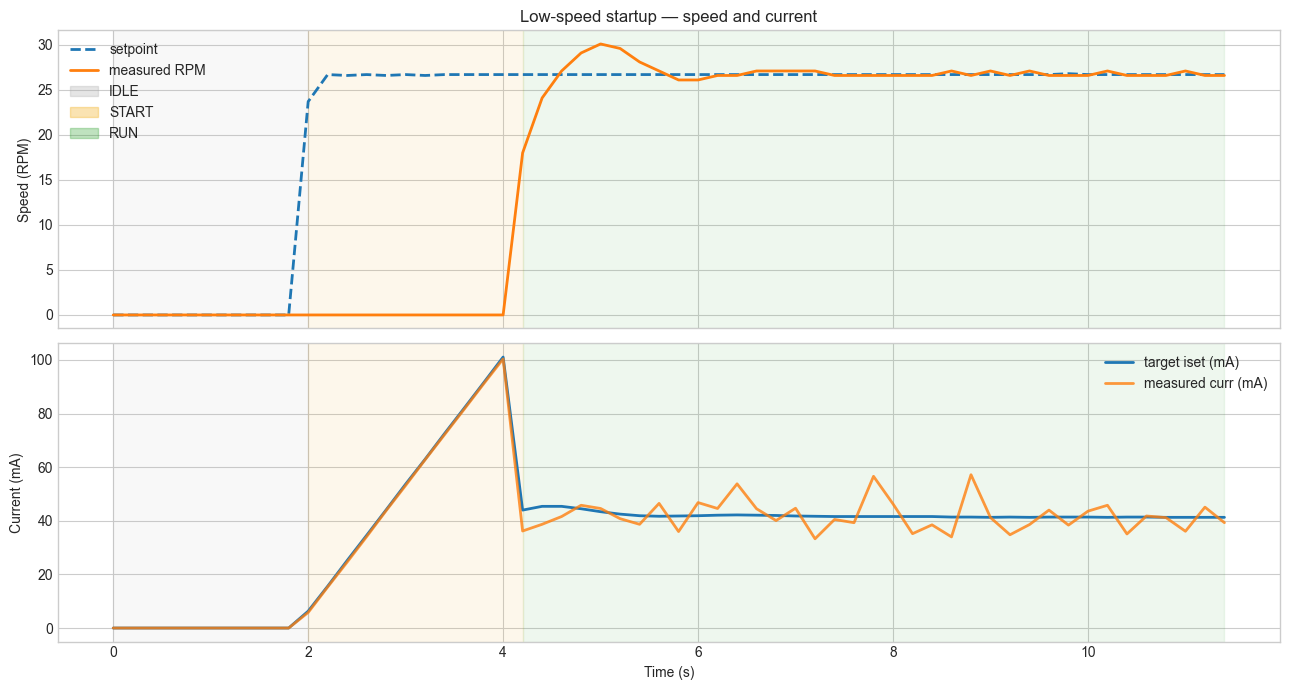

Saved startup_low_speed.pdf / .png


In [4]:
df = dfs["low_startup"]

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
for ax in axes:
    shade_states(ax, df)

patches = [mpatches.Patch(color=c, alpha=0.3, label=s)
           for s, c in STATE_COLOR.items() if s in df["state"].values]
axes[0].plot(df["time_s"], df["set"], label="setpoint", linestyle="--", linewidth=2)
axes[0].plot(df["time_s"], df["rpm"], label="measured RPM", linewidth=2)
axes[0].set_ylabel("Speed (RPM)")
axes[0].set_title("Low-speed startup — speed and current")
axes[0].legend(handles=axes[0].get_lines() + patches,
               labels=[l.get_label() for l in axes[0].get_lines()] + [p.get_label() for p in patches])

axes[1].plot(df["time_s"], df["iset"], label="target iset (mA)", linewidth=2)
axes[1].plot(df["time_s"], df["curr"], label="measured curr (mA)", linewidth=2, alpha=0.8)
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Current (mA)")
axes[1].legend()

plt.tight_layout()
fig.savefig(IMG_DIR / "startup_low_speed.pdf", bbox_inches="tight")
fig.savefig(IMG_DIR / "startup_low_speed.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved startup_low_speed.pdf / .png")

---
## 2  High-speed startup (~100 RPM)

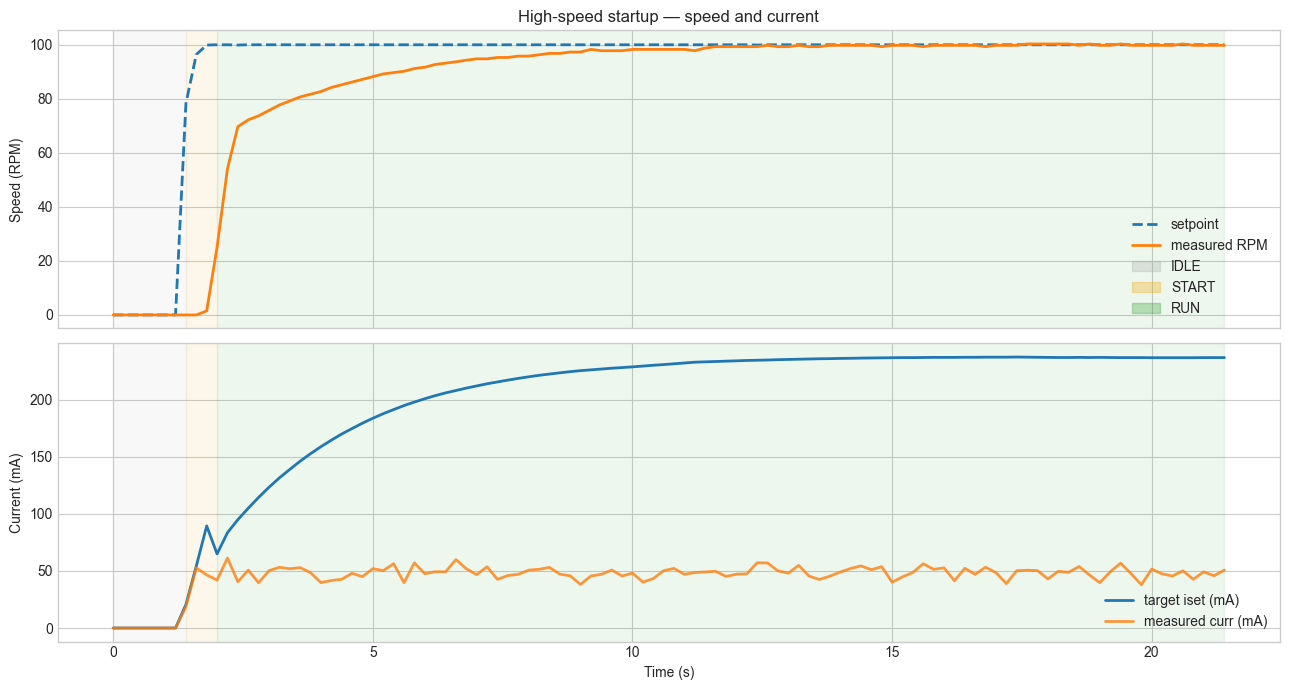

Saved startup_high_speed.pdf / .png


In [5]:
df = dfs["high_startup"]

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
for ax in axes:
    shade_states(ax, df)

patches = [mpatches.Patch(color=c, alpha=0.3, label=s)
           for s, c in STATE_COLOR.items() if s in df["state"].values]
axes[0].plot(df["time_s"], df["set"], label="setpoint", linestyle="--", linewidth=2)
axes[0].plot(df["time_s"], df["rpm"], label="measured RPM", linewidth=2)
axes[0].set_ylabel("Speed (RPM)")
axes[0].set_title("High-speed startup — speed and current")
axes[0].legend(handles=axes[0].get_lines() + patches,
               labels=[l.get_label() for l in axes[0].get_lines()] + [p.get_label() for p in patches])

axes[1].plot(df["time_s"], df["iset"], label="target iset (mA)", linewidth=2)
axes[1].plot(df["time_s"], df["curr"], label="measured curr (mA)", linewidth=2, alpha=0.8)
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Current (mA)")
axes[1].legend()

plt.tight_layout()
fig.savefig(IMG_DIR / "startup_high_speed.pdf", bbox_inches="tight")
fig.savefig(IMG_DIR / "startup_high_speed.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved startup_high_speed.pdf / .png")

---
## 3  Slow ramp to 80 RPM

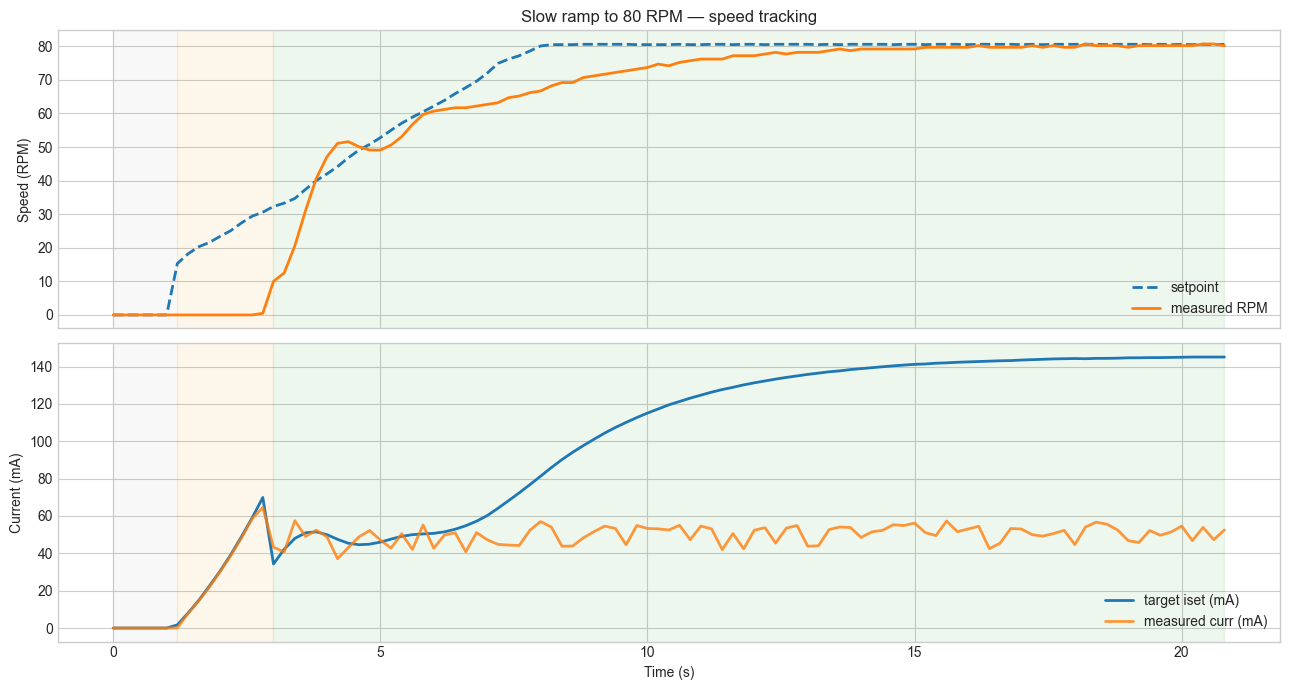

Saved slow_ramp_80rpm.pdf / .png


In [6]:
df = dfs["slow_ramp"]

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
for ax in axes:
    shade_states(ax, df)

axes[0].plot(df["time_s"], df["set"], label="setpoint", linestyle="--", linewidth=2)
axes[0].plot(df["time_s"], df["rpm"], label="measured RPM", linewidth=2)
axes[0].set_ylabel("Speed (RPM)")
axes[0].set_title("Slow ramp to 80 RPM — speed tracking")
axes[0].legend()

axes[1].plot(df["time_s"], df["iset"], label="target iset (mA)", linewidth=2)
axes[1].plot(df["time_s"], df["curr"], label="measured curr (mA)", linewidth=2, alpha=0.8)
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Current (mA)")
axes[1].legend()

plt.tight_layout()
fig.savefig(IMG_DIR / "slow_ramp_80rpm.pdf", bbox_inches="tight")
fig.savefig(IMG_DIR / "slow_ramp_80rpm.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved slow_ramp_80rpm.pdf / .png")

---
## 4  Manual disturbance at 20 RPM

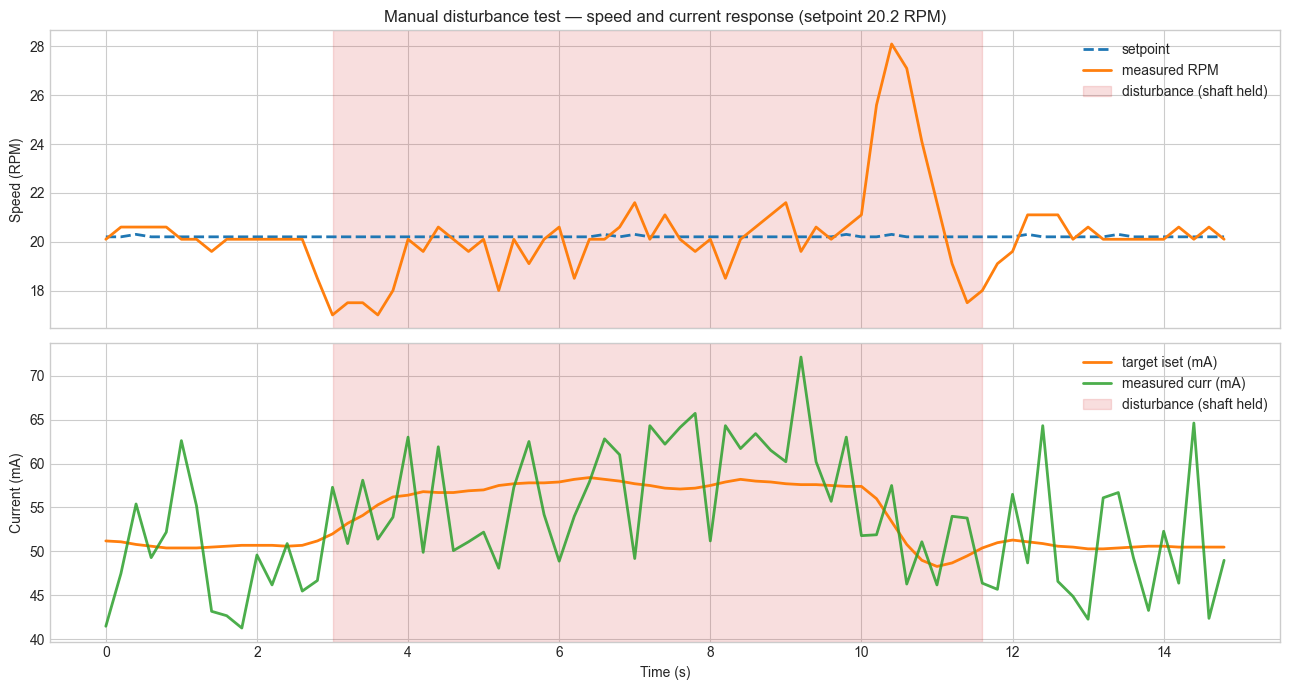

Saved disturbance_20rpm.pdf / .png


In [7]:
df = dfs["disturbance"]

# Detect disturbance window: RPM drops below setpoint by > 2 RPM
rpm_error = df["set"] - df["rpm"]
disturb_mask = rpm_error > 2.0
if disturb_mask.any():
    t_start = df.loc[disturb_mask.idxmax(), "time_s"]
    t_end   = df.loc[disturb_mask[::-1].idxmax(), "time_s"]
else:
    t_start = t_end = None

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

# Top: speed
axes[0].plot(df["time_s"], df["set"], label="setpoint", linestyle="--", linewidth=2, color="tab:blue")
axes[0].plot(df["time_s"], df["rpm"], label="measured RPM", linewidth=2, color="tab:orange")
if t_start is not None:
    axes[0].axvspan(t_start, t_end, alpha=0.15, color="tab:red", label="disturbance (shaft held)")
axes[0].set_ylabel("Speed (RPM)")
axes[0].set_title("Manual disturbance test — speed and current response (setpoint 20.2 RPM)")
axes[0].legend()

# Bottom: current
axes[1].plot(df["time_s"], df["iset"], label="target iset (mA)", linewidth=2, color="tab:orange")
axes[1].plot(df["time_s"], df["curr"], label="measured curr (mA)", linewidth=2, alpha=0.85, color="tab:green")
if t_start is not None:
    axes[1].axvspan(t_start, t_end, alpha=0.15, color="tab:red", label="disturbance (shaft held)")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Current (mA)")
axes[1].legend()

plt.tight_layout()
fig.savefig(IMG_DIR / "disturbance_20rpm.pdf", bbox_inches="tight")
fig.savefig(IMG_DIR / "disturbance_20rpm.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved disturbance_20rpm.pdf / .png")

---
## 5  Steady-state accuracy (RUN phase only)

In [8]:
summary_rows = []
for name, df in dfs.items():
    run = df[df["state"] == "RUN"]
    if run.empty:
        continue
    sp   = run["set"].median()
    mean = run["rpm"].mean()
    lo   = run["rpm"].min()
    hi   = run["rpm"].max()
    err  = (sp - mean) / sp * 100 if sp > 0 else float("nan")
    summary_rows.append({
        "Test":       name,
        "Setpoint":   round(sp, 1),
        "Mean RPM":   round(mean, 2),
        "Min RPM":    round(lo, 1),
        "Max RPM":    round(hi, 1),
        "Error (%)": round(err, 2),
    })

summary = pd.DataFrame(summary_rows)
display(summary)

,Test,Setpoint,Mean RPM,Min RPM,Max RPM,Error (%)
0,low_startup,26.7,26.71,18.0,30.1,-0.02
1,high_startup,100.0,94.41,25.1,100.3,5.59
2,slow_ramp,80.5,70.02,10.0,80.7,13.02
3,disturbance,20.2,20.24,17.0,28.1,-0.19


## Files saved

All figures are written to `report/images/` in both PDF (for LaTeX) and PNG (preview):

- `startup_low_speed.pdf` / `.png`
- `startup_high_speed.pdf` / `.png`
- `slow_ramp_80rpm.pdf` / `.png`
- `disturbance_20rpm.pdf` / `.png`

Include in LaTeX with:
```latex
\includegraphics[width=0.85\textwidth]{images/startup_low_speed.pdf}
```